# Capstone Project: MindTrack
## Aplikasi Deteksi Dini Tingkat Stres Mahasiswa Berdasarkan Pola Aktivitas Digital

**ID Tim Capstone Project:** CC26-PSU024

### Anggota Tim
1. CACC009D6Y1582 - Zidan Putra Wikandana - AI Engineer
2. CDCC596D6X0981 - Dina Salwa Mannatu - Data Scientist
3. CDCC596D6Y2645 - Galih Permana Sidik - Data Scientist
4. CFCC113D6Y2848 - Syahdinmaulana Sadewa Setiawan - Full-Stack Web Developer
5. CACC009D6Y2588 - Rafael Ramdani - AI Engineer
6. CFCC358D6Y1848 - Full-Stack Web Developer

**Deskripsi Proyek:**
Proyek ini bertujuan untuk membangun sistem deteksi dini kesehatan mental bagi mahasiswa berdasarkan pola penggunaan perangkat seluler dan kuesioner psikologis.

# 1. Problem Discovery

## Problem Statement
Mahasiswa sering mengalami stres akibat tekanan akademik, kualitas tidur yang kurang baik, kecemasan, serta aktivitas digital yang tinggi seperti penggunaan smartphone, media sosial, dan aplikasi hiburan. Banyak mahasiswa tidak menyadari tanda awal stres sehingga diperlukan solusi berbasis data untuk membantu mendeteksi pola risiko stres secara lebih dini.

Proyek ini bertujuan menyiapkan dataset dan insight awal untuk mendukung pengembangan aplikasi deteksi dini tingkat stres mahasiswa berdasarkan kondisi mental dan pola aktivitas digital.

## Solusi Utama
Solusi utama yang dikembangkan adalah **MindTrack**, yaitu aplikasi yang nantinya dapat membantu memperkirakan tingkat stres mahasiswa menggunakan Machine Learning berdasarkan data psikologis, akademik, dan pola penggunaan smartphone.

# 2. Business Questions

Pertanyaan bisnis berikut dibuat agar proses analisis data memiliki arah yang jelas dan dapat diukur.

1. Bagaimana hubungan tingkat kecemasan, depresi, dan kualitas tidur terhadap tingkat stres mahasiswa?
2. Bagaimana hubungan beban belajar dan dukungan sosial terhadap tingkat stres mahasiswa?
3. Apakah pola aktivitas digital seperti daily screen time, penggunaan media sosial, dan gaming usage berhubungan dengan tingkat stres mahasiswa?
4. Fitur apa saja yang paling relevan untuk disiapkan sebagai input model Machine Learning?
5. Bagaimana dashboard interaktif dapat membantu menampilkan insight utama terkait stres mahasiswa dan pola aktivitas digital?

Catatan: Pertanyaan terkait akurasi model, training model, dan evaluasi model final tidak dimasukkan sebagai business question Data Scientist karena bagian tersebut menjadi tanggung jawab utama AI Engineer.

# 3. Import Library

Library digunakan untuk membaca data, membersihkan data, melakukan analisis eksploratif, membuat visualisasi, menjalankan A/B testing sederhana, serta menyiapkan file output untuk handover ke AI Engineer.

In [1]:
import os
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# 4. Data Wrangling: Gathering Data

Tahap gathering data dilakukan dengan mengumpulkan dua dataset utama:

1. **StressLevelDataset.csv** berisi indikator psikologis, akademik, sosial, dan label tingkat stres mahasiswa.
2. **mobile_usage_behavioral_analysis.csv** berisi pola penggunaan smartphone seperti screen time, penggunaan media sosial, aplikasi produktivitas, dan gaming.

Kedua dataset berasal dari sumber publik Kaggle dan digunakan untuk membangun dataset gabungan yang merepresentasikan kesehatan mental dan pola aktivitas digital.

In [2]:
# Path dataset untuk Google Colab
stress_path = '/content/StressLevelDataset.csv'
phone_path = '/content/mobile_usage_behavioral_analysis.csv'

# Fallback path jika notebook dijalankan di environment lokal
if not os.path.exists(stress_path):
    stress_path = '/mnt/data/StressLevelDataset.csv'
if not os.path.exists(phone_path):
    phone_path = '/mnt/data/mobile_usage_behavioral_analysis.csv'

stress_df = pd.read_csv(stress_path)
phone_df = pd.read_csv(phone_path)

print('Stress Dataset Shape:', stress_df.shape)
print('Phone Dataset Shape:', phone_df.shape)

display(stress_df.head())
display(phone_df.head())

Stress Dataset Shape: (1100, 21)
Phone Dataset Shape: (1000, 10)


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,3,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,2,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,3,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,2,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,4,3,4,3,1,2,1,5,0,5,1


,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1,56,Male,2.61,7.15,24,4.43,0.55,2.40,Los Angeles
1,2,46,Male,2.13,13.79,18,4.67,4.42,2.43,Chicago
2,3,32,Female,7.28,4.50,11,4.58,1.71,2.83,Houston
3,4,25,Female,1.20,6.29,21,3.18,3.42,4.58,Phoenix
4,5,38,Male,6.31,12.59,14,3.15,0.13,4.00,New York


## Insight Awal dari Data Preview

Dari tampilan awal dataset, dataset stres memiliki fitur psikologis seperti `anxiety_level`, `depression`, `sleep_quality`, `study_load`, dan `stress_level`. Dataset smartphone memiliki fitur aktivitas digital seperti `Daily_Screen_Time_Hours`, `Social_Media_Usage_Hours`, `Productivity_App_Usage_Hours`, dan `Gaming_App_Usage_Hours`.

Gabungan kedua dataset ini relevan untuk menjawab masalah proyek karena dapat menghubungkan kondisi mental mahasiswa dengan pola aktivitas digital.

# 5. Data Wrangling: Assessing Data

Tahap assessing data bertujuan mengevaluasi struktur dan kualitas data sebelum cleaning. Pemeriksaan mencakup:

- jumlah baris dan kolom
- tipe data
- missing value
- data duplikat
- statistik deskriptif
- konsistensi nama kolom

In [3]:
print('=== Info Stress Dataset ===')
stress_df.info()

print('\n=== Info Phone Dataset ===')
phone_df.info()

print('\n=== Missing Value Stress Dataset ===')
display(stress_df.isnull().sum().to_frame('missing_count'))

print('\n=== Missing Value Phone Dataset ===')
display(phone_df.isnull().sum().to_frame('missing_count'))

print('\nDuplicate Stress Dataset:', stress_df.duplicated().sum())
print('Duplicate Phone Dataset:', phone_df.duplicated().sum())

print('\n=== Statistik Deskriptif Stress Dataset ===')
display(stress_df.describe())

print('\n=== Statistik Deskriptif Phone Dataset ===')
display(phone_df.describe())

=== Info Stress Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study

,missing_count
anxiety_level,0
self_esteem,0
mental_health_history,0
depression,0
headache,0
blood_pressure,0
sleep_quality,0
breathing_problem,0
noise_level,0
living_conditions,0



=== Missing Value Phone Dataset ===


,missing_count
User_ID,0
Age,0
Gender,0
Total_App_Usage_Hours,0
Daily_Screen_Time_Hours,0
Number_of_Apps_Used,0
Social_Media_Usage_Hours,0
Productivity_App_Usage_Hours,0
Gaming_App_Usage_Hours,0
Location,0



Duplicate Stress Dataset: 0
Duplicate Phone Dataset: 0

=== Statistik Deskriptif Stress Dataset ===


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,2.737273,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,1.406171,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000



=== Statistik Deskriptif Phone Dataset ===


,User_ID,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,38.745000,6.405670,7.696310,16.64700,2.456330,2.495270,2.475410
std,288.819436,12.186734,3.134855,3.714187,7.61961,1.439525,1.443392,1.450362
min,1.000000,18.000000,1.000000,1.010000,3.00000,0.000000,0.000000,0.010000
25%,250.750000,28.000000,3.590000,4.530000,10.00000,1.200000,1.282500,1.220000
50%,500.500000,40.000000,6.455000,7.880000,17.00000,2.445000,2.435000,2.455000
75%,750.250000,50.000000,9.122500,10.910000,23.00000,3.672500,3.710000,3.782500
max,1000.000000,59.000000,11.970000,14.000000,29.00000,4.990000,5.000000,5.000000


## Catatan Assessing Data

Hasil assessing digunakan untuk menentukan tindakan cleaning. Jika terdapat missing value atau duplikasi, data akan dibersihkan sebelum masuk tahap analisis. Proses ini penting agar tidak menggunakan dataset mentah secara langsung tanpa pembersihan manual.

# 6. Data Wrangling: Cleaning Data

Tahap cleaning data dilakukan untuk memastikan data siap dianalisis. Langkah yang dilakukan:

1. Menyalin dataset asli agar data mentah tetap aman.
2. Merapikan nama kolom.
3. Menghapus data duplikat.
4. Menghapus missing value.
5. Memilih fitur yang relevan dengan problem statement.

Tahap ini memenuhi checklist cleaning data sebelum masuk ke tahap analisis.

In [4]:
stress_clean = stress_df.copy()
phone_clean = phone_df.copy()

# Merapikan nama kolom
stress_clean.columns = stress_clean.columns.str.strip()
phone_clean.columns = phone_clean.columns.str.strip()

# Menghapus duplikasi
stress_clean = stress_clean.drop_duplicates()
phone_clean = phone_clean.drop_duplicates()

# Menghapus missing value
stress_clean = stress_clean.dropna()
phone_clean = phone_clean.dropna()

print('Stress Clean Shape:', stress_clean.shape)
print('Phone Clean Shape:', phone_clean.shape)

Stress Clean Shape: (1100, 21)
Phone Clean Shape: (1000, 10)


# 7. Feature Selection Awal

Fitur dipilih berdasarkan relevansinya terhadap masalah deteksi tingkat stres mahasiswa.

### Fitur dari Stress Dataset
- `anxiety_level`
- `self_esteem`
- `mental_health_history`
- `depression`
- `headache`
- `sleep_quality`
- `academic_performance`
- `study_load`
- `future_career_concerns`
- `social_support`
- `peer_pressure`
- `bullying`
- `stress_level` sebagai target

### Fitur dari Smartphone Usage Dataset
- `Age`
- `Total_App_Usage_Hours`
- `Daily_Screen_Time_Hours`
- `Number_of_Apps_Used`
- `Social_Media_Usage_Hours`
- `Productivity_App_Usage_Hours`
- `Gaming_App_Usage_Hours`

Pemilihan fitur ini dilakukan agar dataset akhir tetap fokus pada faktor mental, akademik, sosial, dan digital.

In [5]:
stress_feature_columns = [
    'anxiety_level',
    'self_esteem',
    'mental_health_history',
    'depression',
    'headache',
    'sleep_quality',
    'academic_performance',
    'study_load',
    'future_career_concerns',
    'social_support',
    'peer_pressure',
    'bullying',
    'stress_level'
]

phone_feature_columns = [
    'Age',
    'Total_App_Usage_Hours',
    'Daily_Screen_Time_Hours',
    'Number_of_Apps_Used',
    'Social_Media_Usage_Hours',
    'Productivity_App_Usage_Hours',
    'Gaming_App_Usage_Hours'
]

stress_features = stress_clean[stress_feature_columns].copy()
phone_features = phone_clean[phone_feature_columns].copy()

print('Stress Features Shape:', stress_features.shape)
print('Phone Features Shape:', phone_features.shape)

Stress Features Shape: (1100, 13)
Phone Features Shape: (1000, 7)


# 8. Data Integration

Kedua dataset tidak memiliki `user_id` yang sama, sehingga penggabungan dilakukan berdasarkan index setelah jumlah baris disamakan. Pendekatan ini digunakan sebagai simulasi data capstone untuk menggabungkan faktor kesehatan mental dan faktor aktivitas digital.

Keterbatasan ini perlu dicatat dalam laporan agar proses analisis tetap transparan.

In [6]:
min_rows = min(len(stress_features), len(phone_features))

stress_features = stress_features.iloc[:min_rows].reset_index(drop=True)
phone_features = phone_features.iloc[:min_rows].reset_index(drop=True)

final_df = pd.concat([stress_features, phone_features], axis=1)

print('Final Dataset Shape:', final_df.shape)
display(final_df.head())

Final Dataset Shape: (1000, 20)


,anxiety_level,self_esteem,mental_health_history,depression,headache,sleep_quality,academic_performance,study_load,future_career_concerns,social_support,peer_pressure,bullying,stress_level,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours
0,14,20,0,11,2,2,3,2,3,2,3,2,1,56,2.61,7.15,24,4.43,0.55,2.40
1,15,8,1,15,5,1,1,4,5,1,4,5,2,46,2.13,13.79,18,4.67,4.42,2.43
2,12,18,1,14,2,2,2,3,2,2,3,2,1,32,7.28,4.50,11,4.58,1.71,2.83
3,16,12,1,15,4,1,2,4,4,1,4,5,2,25,1.20,6.29,21,3.18,3.42,4.58
4,16,28,0,7,2,5,4,3,2,1,5,5,1,38,6.31,12.59,14,3.15,0.13,4.00


# 9. Final Data Quality Check dan Pencegahan Data Leakage

Sebelum analisis dan handover, dataset akhir diperiksa kembali. Target `stress_level` harus dipisahkan dari fitur input saat digunakan oleh AI Engineer agar tidak terjadi **data leakage**.

Data leakage terjadi ketika informasi target secara tidak sengaja masuk ke fitur training sehingga model terlihat bagus tetapi tidak valid.

In [7]:
print('=== Missing Value Final Dataset ===')
display(final_df.isnull().sum().to_frame('missing_count'))

print('Duplicate Final Dataset:', final_df.duplicated().sum())

final_df = final_df.dropna().drop_duplicates().reset_index(drop=True)

target_column = 'stress_level'
feature_columns = [col for col in final_df.columns if col != target_column]

print('Target column:', target_column)
print('Jumlah fitur input:', len(feature_columns))
print('Data leakage check:', target_column not in feature_columns)

print('\nFitur input untuk AI Engineer:')
for col in feature_columns:
    print('-', col)

=== Missing Value Final Dataset ===


,missing_count
anxiety_level,0
self_esteem,0
mental_health_history,0
depression,0
headache,0
sleep_quality,0
academic_performance,0
study_load,0
future_career_concerns,0
social_support,0


Duplicate Final Dataset: 0
Target column: stress_level
Jumlah fitur input: 19
Data leakage check: True

Fitur input untuk AI Engineer:
- anxiety_level
- self_esteem
- mental_health_history
- depression
- headache
- sleep_quality
- academic_performance
- study_load
- future_career_concerns
- social_support
- peer_pressure
- bullying
- Age
- Total_App_Usage_Hours
- Daily_Screen_Time_Hours
- Number_of_Apps_Used
- Social_Media_Usage_Hours
- Productivity_App_Usage_Hours
- Gaming_App_Usage_Hours


# 10. Exploratory Data Analysis (EDA)

EDA dilakukan untuk menemukan pola awal dari data dan menjawab business questions. Visualisasi yang dibuat mencakup distribusi target, hubungan fitur mental dengan stres, hubungan pola digital dengan stres, dan korelasi antar fitur.

## 10.1 Distribusi Stress Level

Visualisasi ini digunakan untuk melihat persebaran label target. Distribusi target penting agar AI Engineer mengetahui apakah data relatif seimbang atau terdapat class imbalance.

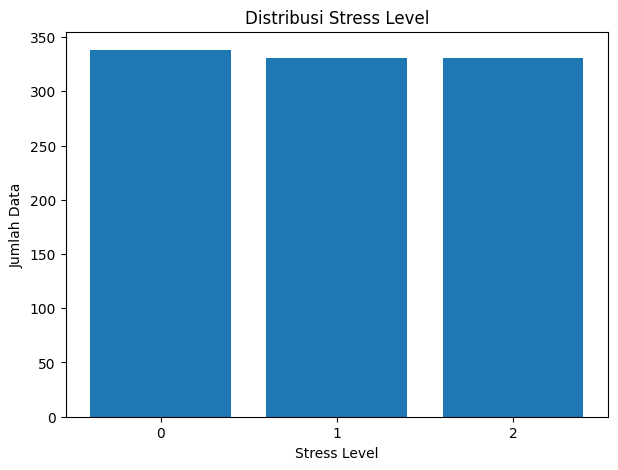

,count
stress_level,
0,338
1,331
2,331


In [8]:
stress_counts = final_df['stress_level'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(stress_counts.index.astype(str), stress_counts.values)
plt.title('Distribusi Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Jumlah Data')
plt.show()

display(stress_counts.to_frame('count'))

## 10.2 Anxiety Level berdasarkan Stress Level

Analisis ini digunakan untuk melihat apakah mahasiswa dengan tingkat stres yang lebih tinggi cenderung memiliki anxiety level yang lebih tinggi.

<Figure size 700x500 with 0 Axes>

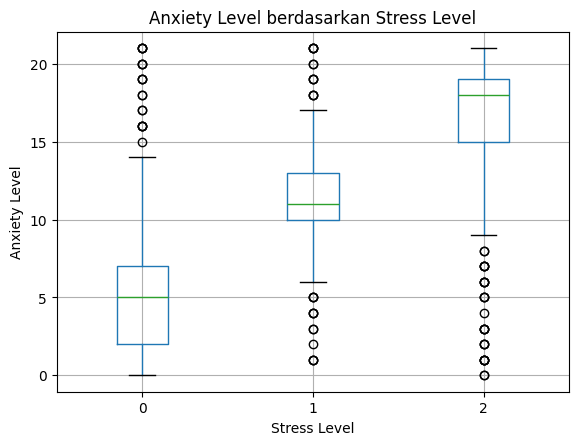

In [9]:
plt.figure(figsize=(7, 5))
final_df.boxplot(column='anxiety_level', by='stress_level')
plt.title('Anxiety Level berdasarkan Stress Level')
plt.suptitle('')
plt.xlabel('Stress Level')
plt.ylabel('Anxiety Level')
plt.show()

## 10.3 Sleep Quality berdasarkan Stress Level

Analisis ini digunakan untuk melihat hubungan kualitas tidur dengan tingkat stres mahasiswa.

<Figure size 700x500 with 0 Axes>

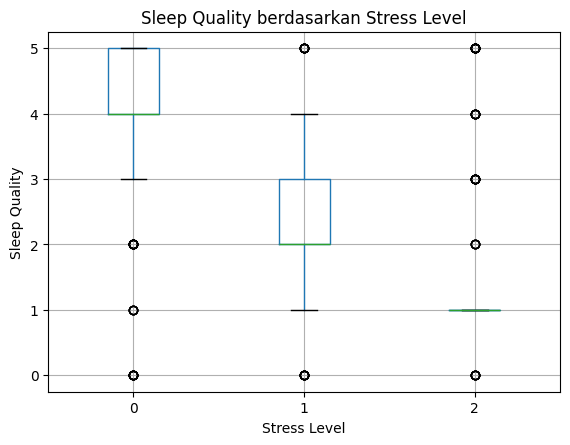

In [10]:
plt.figure(figsize=(7, 5))
final_df.boxplot(column='sleep_quality', by='stress_level')
plt.title('Sleep Quality berdasarkan Stress Level')
plt.suptitle('')
plt.xlabel('Stress Level')
plt.ylabel('Sleep Quality')
plt.show()

## 10.4 Daily Screen Time berdasarkan Stress Level

Visualisasi ini digunakan untuk melihat apakah durasi screen time harian memiliki pola tertentu terhadap tingkat stres mahasiswa.

<Figure size 700x500 with 0 Axes>

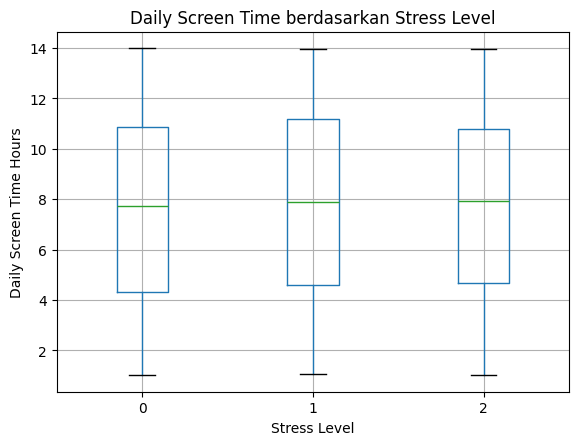

In [11]:
plt.figure(figsize=(7, 5))
final_df.boxplot(column='Daily_Screen_Time_Hours', by='stress_level')
plt.title('Daily Screen Time berdasarkan Stress Level')
plt.suptitle('')
plt.xlabel('Stress Level')
plt.ylabel('Daily Screen Time Hours')
plt.show()

## 10.5 Social Media Usage berdasarkan Stress Level

Visualisasi ini digunakan untuk menganalisis hubungan durasi penggunaan media sosial dengan tingkat stres.

<Figure size 700x500 with 0 Axes>

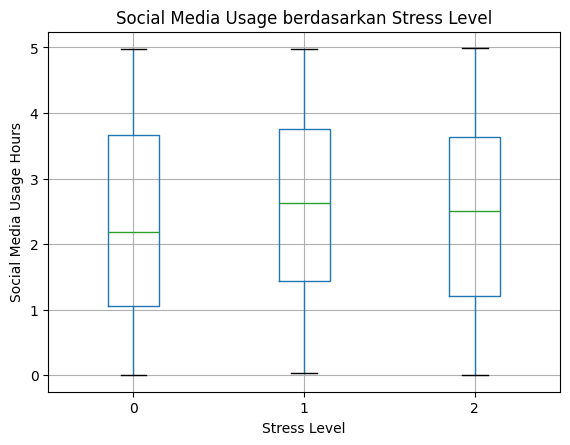

In [12]:
plt.figure(figsize=(7, 5))
final_df.boxplot(column='Social_Media_Usage_Hours', by='stress_level')
plt.title('Social Media Usage berdasarkan Stress Level')
plt.suptitle('')
plt.xlabel('Stress Level')
plt.ylabel('Social Media Usage Hours')
plt.show()

## 10.6 Correlation Analysis

Analisis korelasi digunakan untuk melihat hubungan antar fitur numerik, terutama fitur yang memiliki hubungan dengan `stress_level`. Hasil ini membantu proses feature selection dan handover kepada AI Engineer.

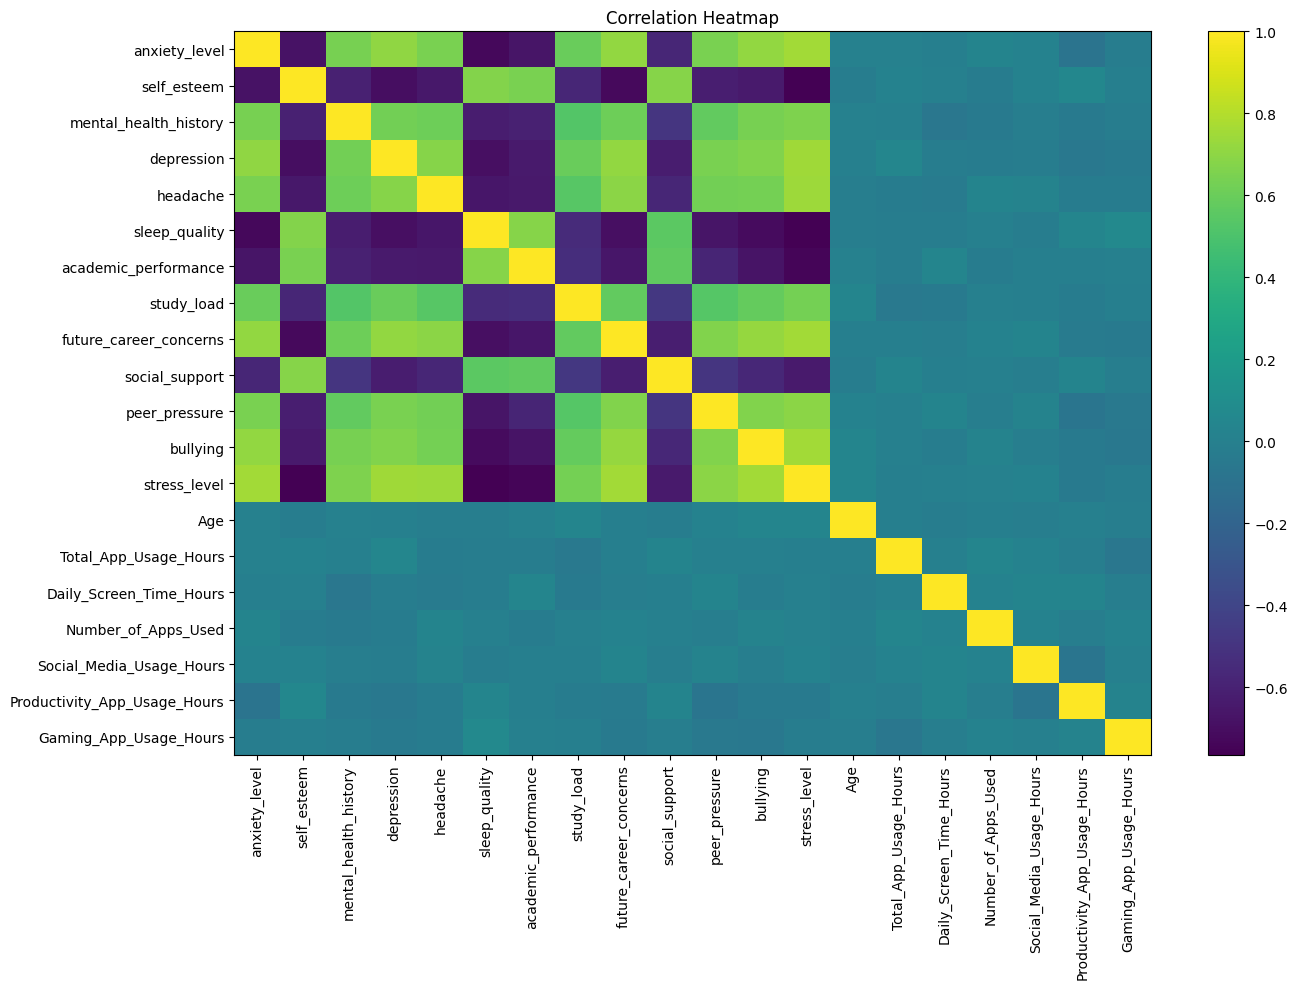

,correlation_with_stress_level
stress_level,1.000000
future_career_concerns,0.756913
bullying,0.753232
anxiety_level,0.753029
depression,0.751243
headache,0.739005
peer_pressure,0.695177
mental_health_history,0.661400
study_load,0.631980
Age,0.041477


In [13]:
correlation = final_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
plt.imshow(correlation, aspect='auto')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

stress_corr = correlation['stress_level'].sort_values(ascending=False)
display(stress_corr.to_frame('correlation_with_stress_level'))

# 11. Explanatory Analysis

Berdasarkan EDA, analisis diarahkan untuk menjawab business questions. Penjelasan ini penting agar hasil analisis tidak hanya berupa angka atau grafik, tetapi juga memberikan interpretasi yang dapat digunakan untuk pengambilan keputusan proyek.

In [14]:
eda_insights = []

if 'anxiety_level' in stress_corr.index:
    eda_insights.append(f"Korelasi anxiety_level terhadap stress_level: {stress_corr['anxiety_level']:.3f}")
if 'depression' in stress_corr.index:
    eda_insights.append(f"Korelasi depression terhadap stress_level: {stress_corr['depression']:.3f}")
if 'sleep_quality' in stress_corr.index:
    eda_insights.append(f"Korelasi sleep_quality terhadap stress_level: {stress_corr['sleep_quality']:.3f}")
if 'Daily_Screen_Time_Hours' in stress_corr.index:
    eda_insights.append(f"Korelasi Daily_Screen_Time_Hours terhadap stress_level: {stress_corr['Daily_Screen_Time_Hours']:.3f}")
if 'Social_Media_Usage_Hours' in stress_corr.index:
    eda_insights.append(f"Korelasi Social_Media_Usage_Hours terhadap stress_level: {stress_corr['Social_Media_Usage_Hours']:.3f}")

for insight in eda_insights:
    print('-', insight)

- Korelasi anxiety_level terhadap stress_level: 0.753
- Korelasi depression terhadap stress_level: 0.751
- Korelasi sleep_quality terhadap stress_level: -0.765
- Korelasi Daily_Screen_Time_Hours terhadap stress_level: 0.007
- Korelasi Social_Media_Usage_Hours terhadap stress_level: 0.015


## Ringkasan Insight EDA

1. Fitur psikologis seperti kecemasan dan depresi perlu diperhatikan karena secara konseptual sangat relevan dengan tingkat stres mahasiswa.
2. Kualitas tidur menjadi indikator penting karena perubahan pola tidur sering berkaitan dengan kesejahteraan mental.
3. Pola aktivitas digital seperti screen time, media sosial, dan gaming usage dapat digunakan sebagai fitur pendukung dalam deteksi dini tingkat stres.
4. Dataset akhir perlu diserahkan kepada AI Engineer dalam kondisi bersih, terdokumentasi, dan bebas dari data leakage.

# 12. Side Quest: Feature Engineering

Feature engineering dilakukan untuk membuat fitur baru yang lebih informatif bagi model. Fitur baru dibuat dari kombinasi fitur yang sudah ada.

Fitur baru yang dibuat:

1. `digital_overload_score`: gabungan screen time, media sosial, dan gaming.
2. `productivity_balance_score`: rasio penggunaan aplikasi produktivitas terhadap total penggunaan aplikasi.
3. `study_stress_ratio`: rasio beban belajar terhadap kualitas tidur.
4. `mental_risk_score`: gabungan indikator kecemasan, depresi, tekanan teman sebaya, dan bullying.

Fitur ini nantinya dapat diuji lebih lanjut oleh AI Engineer saat proses modeling.

In [15]:
final_df['digital_overload_score'] = (
    final_df['Daily_Screen_Time_Hours'] +
    final_df['Social_Media_Usage_Hours'] +
    final_df['Gaming_App_Usage_Hours']
)

final_df['productivity_balance_score'] = (
    final_df['Productivity_App_Usage_Hours'] /
    (final_df['Total_App_Usage_Hours'] + 1)
)

final_df['study_stress_ratio'] = (
    final_df['study_load'] /
    (final_df['sleep_quality'] + 1)
)

final_df['mental_risk_score'] = (
    final_df['anxiety_level'] +
    final_df['depression'] +
    final_df['peer_pressure'] +
    final_df['bullying']
)

display(final_df.head())

,anxiety_level,self_esteem,mental_health_history,depression,headache,sleep_quality,academic_performance,study_load,future_career_concerns,social_support,peer_pressure,bullying,stress_level,Age,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,digital_overload_score,productivity_balance_score,study_stress_ratio,mental_risk_score
0,14,20,0,11,2,2,3,2,3,2,3,2,1,56,2.61,7.15,24,4.43,0.55,2.40,13.98,0.152355,0.666667,30
1,15,8,1,15,5,1,1,4,5,1,4,5,2,46,2.13,13.79,18,4.67,4.42,2.43,20.89,1.412141,2.000000,39
2,12,18,1,14,2,2,2,3,2,2,3,2,1,32,7.28,4.50,11,4.58,1.71,2.83,11.91,0.206522,1.000000,31
3,16,12,1,15,4,1,2,4,4,1,4,5,2,25,1.20,6.29,21,3.18,3.42,4.58,14.05,1.554545,2.000000,40
4,16,28,0,7,2,5,4,3,2,1,5,5,1,38,6.31,12.59,14,3.15,0.13,4.00,19.74,0.017784,0.500000,33


# 13. Side Quest: A/B Testing Menggunakan Python

A/B testing sederhana dilakukan untuk membandingkan rata-rata `stress_level` antara dua kelompok:

- **Group A:** mahasiswa dengan `digital_overload_score` rendah atau sama dengan median.
- **Group B:** mahasiswa dengan `digital_overload_score` tinggi di atas median.

Tujuannya adalah melihat apakah kelompok dengan beban digital tinggi memiliki rata-rata tingkat stres yang berbeda dibanding kelompok dengan beban digital rendah.

In [16]:
median_overload = final_df['digital_overload_score'].median()

group_a = final_df[final_df['digital_overload_score'] <= median_overload]['stress_level']
group_b = final_df[final_df['digital_overload_score'] > median_overload]['stress_level']

t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

print('Median Digital Overload Score:', median_overload)
print('Mean Stress Level Group A (Low Digital Overload):', group_a.mean())
print('Mean Stress Level Group B (High Digital Overload):', group_b.mean())
print('T-statistic:', t_stat)
print('P-value:', p_value)

if p_value < 0.05:
    print('Kesimpulan: terdapat perbedaan rata-rata stress level yang signifikan antara kedua kelompok.')
else:
    print('Kesimpulan: belum terdapat perbedaan rata-rata stress level yang signifikan antara kedua kelompok.')

Median Digital Overload Score: 12.715
Mean Stress Level Group A (Low Digital Overload): 0.974
Mean Stress Level Group B (High Digital Overload): 1.012
T-statistic: -0.7340724637444527
P-value: 0.46307700007907315
Kesimpulan: belum terdapat perbedaan rata-rata stress level yang signifikan antara kedua kelompok.


# 14. Data Dictionary

Data dictionary dibuat untuk mendokumentasikan setiap fitur dalam dataset akhir. Dokumen ini membantu AI Engineer dan Full Stack Web Developer memahami arti setiap kolom yang digunakan.

In [17]:
descriptions = {
    'anxiety_level': 'Tingkat kecemasan mahasiswa.',
    'self_esteem': 'Tingkat kepercayaan diri mahasiswa.',
    'mental_health_history': 'Riwayat kesehatan mental.',
    'depression': 'Tingkat depresi mahasiswa.',
    'headache': 'Intensitas sakit kepala.',
    'sleep_quality': 'Kualitas tidur mahasiswa.',
    'academic_performance': 'Performa akademik mahasiswa.',
    'study_load': 'Beban belajar mahasiswa.',
    'future_career_concerns': 'Kekhawatiran terhadap karier masa depan.',
    'social_support': 'Dukungan sosial yang diterima mahasiswa.',
    'peer_pressure': 'Tekanan dari teman sebaya.',
    'bullying': 'Pengalaman bullying.',
    'stress_level': 'Target atau label tingkat stres mahasiswa.',
    'Age': 'Usia pengguna smartphone.',
    'Total_App_Usage_Hours': 'Total durasi penggunaan aplikasi per hari.',
    'Daily_Screen_Time_Hours': 'Durasi screen time harian.',
    'Number_of_Apps_Used': 'Jumlah aplikasi yang digunakan.',
    'Social_Media_Usage_Hours': 'Durasi penggunaan media sosial.',
    'Productivity_App_Usage_Hours': 'Durasi penggunaan aplikasi produktivitas.',
    'Gaming_App_Usage_Hours': 'Durasi penggunaan aplikasi game.',
    'digital_overload_score': 'Skor gabungan penggunaan digital berlebih.',
    'productivity_balance_score': 'Rasio penggunaan aplikasi produktivitas terhadap total penggunaan aplikasi.',
    'study_stress_ratio': 'Rasio beban belajar terhadap kualitas tidur.',
    'mental_risk_score': 'Skor gabungan risiko mental dari beberapa indikator psikologis dan sosial.'
}

data_dictionary = pd.DataFrame({
    'column_name': final_df.columns,
    'description': [descriptions.get(col, 'Deskripsi belum tersedia.') for col in final_df.columns],
    'data_type': [str(final_df[col].dtype) for col in final_df.columns],
    'role': ['target' if col == 'stress_level' else 'feature' for col in final_df.columns]
})

display(data_dictionary)

,column_name,description,data_type,role
0,anxiety_level,Tingkat kecemasan mahasiswa.,int64,feature
1,self_esteem,Tingkat kepercayaan diri mahasiswa.,int64,feature
2,mental_health_history,Riwayat kesehatan mental.,int64,feature
3,depression,Tingkat depresi mahasiswa.,int64,feature
4,headache,Intensitas sakit kepala.,int64,feature
5,sleep_quality,Kualitas tidur mahasiswa.,int64,feature
6,academic_performance,Performa akademik mahasiswa.,int64,feature
7,study_load,Beban belajar mahasiswa.,int64,feature
8,future_career_concerns,Kekhawatiran terhadap karier masa depan.,int64,feature
9,social_support,Dukungan sosial yang diterima mahasiswa.,int64,feature


# 15. Dataset Final Siap Modeling

Dataset final disimpan dalam bentuk CSV. File ini menjadi output utama dari tim Data Scientist dan akan diserahkan kepada AI Engineer untuk proses modeling.

Output yang disiapkan:

- `final_clean_dataset.csv`
- `selected_features.txt`
- `data_dictionary.csv`
- `eda_summary.txt`
- `ab_testing_result.txt`

In [18]:
output_dir = '/content/data_science_output'
if not os.path.exists('/content'):
    output_dir = '/mnt/data/data_science_output'

os.makedirs(output_dir, exist_ok=True)

final_dataset_path = os.path.join(output_dir, 'final_clean_dataset.csv')
data_dictionary_path = os.path.join(output_dir, 'data_dictionary.csv')
selected_features_path = os.path.join(output_dir, 'selected_features.txt')
eda_summary_path = os.path.join(output_dir, 'eda_summary.txt')
ab_result_path = os.path.join(output_dir, 'ab_testing_result.txt')

final_df.to_csv(final_dataset_path, index=False)
data_dictionary.to_csv(data_dictionary_path, index=False)

selected_features = [col for col in final_df.columns if col != 'stress_level']
with open(selected_features_path, 'w') as f:
    for feature in selected_features:
        f.write(feature + '\n')

with open(eda_summary_path, 'w') as f:
    f.write('Problem Statement:\n')
    f.write('Deteksi dini tingkat stres mahasiswa berdasarkan kondisi mental dan pola aktivitas digital.\n\n')
    f.write('Business Questions:\n')
    f.write('1. Hubungan anxiety, depression, sleep quality dengan stress level.\n')
    f.write('2. Hubungan study load dan social support dengan stress level.\n')
    f.write('3. Hubungan screen time dan social media usage dengan stress level.\n')
    f.write('4. Fitur relevan untuk input model Machine Learning.\n\n')
    f.write('EDA Insights:\n')
    for insight in eda_insights:
        f.write('- ' + insight + '\n')

with open(ab_result_path, 'w') as f:
    f.write(f'Median Digital Overload Score: {median_overload}\n')
    f.write(f'Mean Stress Level Group A: {group_a.mean()}\n')
    f.write(f'Mean Stress Level Group B: {group_b.mean()}\n')
    f.write(f'T-statistic: {t_stat}\n')
    f.write(f'P-value: {p_value}\n')

print('Output berhasil disimpan di:', output_dir)
print('- final_clean_dataset.csv')
print('- selected_features.txt')
print('- data_dictionary.csv')
print('- eda_summary.txt')
print('- ab_testing_result.txt')

Output berhasil disimpan di: /content/data_science_output
- final_clean_dataset.csv
- selected_features.txt
- data_dictionary.csv
- eda_summary.txt
- ab_testing_result.txt


# 16. Main Quest dan Side Quest: Dashboard Interaktif Streamlit

Dashboard interaktif dibuat menggunakan Streamlit untuk menampilkan insight dan kesimpulan EDA. Dashboard ini dapat digunakan oleh tim untuk menjelaskan hasil analisis kepada reviewer.

Dashboard menampilkan:

- preview dataset
- distribusi stress level
- visualisasi screen time terhadap stress
- visualisasi social media usage terhadap stress
- korelasi fitur terhadap stress level
- ringkasan insight

In [19]:
streamlit_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title='MindTrack Dashboard', layout='wide')

st.title('MindTrack: Dashboard Insight Tingkat Stres Mahasiswa')
st.write('Dashboard ini menampilkan insight dari data kesehatan mental dan pola aktivitas digital mahasiswa.')

df = pd.read_csv('final_clean_dataset.csv')

st.subheader('Preview Dataset')
st.dataframe(df.head())

st.subheader('Distribusi Stress Level')
stress_count = df['stress_level'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(stress_count.index.astype(str), stress_count.values)
ax.set_xlabel('Stress Level')
ax.set_ylabel('Jumlah Data')
ax.set_title('Distribusi Stress Level')
st.pyplot(fig)

st.subheader('Daily Screen Time berdasarkan Stress Level')
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column='Daily_Screen_Time_Hours', by='stress_level', ax=ax)
plt.suptitle('')
ax.set_title('Daily Screen Time berdasarkan Stress Level')
st.pyplot(fig)

st.subheader('Social Media Usage berdasarkan Stress Level')
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column='Social_Media_Usage_Hours', by='stress_level', ax=ax)
plt.suptitle('')
ax.set_title('Social Media Usage berdasarkan Stress Level')
st.pyplot(fig)

st.subheader('Korelasi terhadap Stress Level')
corr = df.corr(numeric_only=True)['stress_level'].sort_values(ascending=False)
st.dataframe(corr)

st.subheader('Kesimpulan')
st.write('Fitur mental, akademik, sosial, dan aktivitas digital dapat digunakan sebagai kandidat fitur untuk tahap modeling oleh AI Engineer.')
"""

app_path = os.path.join(output_dir, 'app.py')
with open(app_path, 'w') as f:
    f.write(streamlit_code)

requirements_path = os.path.join(output_dir, 'requirements.txt')
with open(requirements_path, 'w') as f:
    f.write('streamlit\npandas\nmatplotlib\nscipy\n')

print('File dashboard berhasil dibuat:')
print('- app.py')
print('- requirements.txt')

File dashboard berhasil dibuat:
- app.py
- requirements.txt


## Link Deployment Dashboard
Dashboard interaktif hasil eksplorasi dan analisis data telah berhasil dideploy menggunakan Streamlit Cloud dan dapat diakses melalui tautan berikut:

Dashboard MindTrack:
https://dashboard-mindtrack.streamlit.app/

Dashboard ini digunakan untuk menampilkan insight utama dari data, seperti distribusi tingkat stres, hubungan aktivitas digital dengan stres, serta visualisasi fitur yang relevan untuk mendukung proses analisis sebelum tahap pemodelan oleh AI Engineer

# 17. Side Quest: Laporan Teknis PDF

Laporan teknis dibuat untuk merangkum proses Data Science dari problem discovery sampai dataset siap modeling. File PDF ini dapat digunakan sebagai lampiran dokumentasi proyek.

In [20]:
# Membuat laporan teknis PDF sederhana
# Jika dijalankan di Colab, install reportlab jika belum tersedia
try:
    from reportlab.lib.pagesizes import A4
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
    from reportlab.lib.styles import getSampleStyleSheet
except ImportError:
    import sys
    !{sys.executable} -m pip install reportlab -q
    from reportlab.lib.pagesizes import A4
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
    from reportlab.lib.styles import getSampleStyleSheet

pdf_path = os.path.join(output_dir, 'technical_report_data_science.pdf')
styles = getSampleStyleSheet()
doc = SimpleDocTemplate(pdf_path, pagesize=A4)
story = []

story.append(Paragraph('Technical Report Data Science - MindTrack', styles['Title']))
story.append(Spacer(1, 12))
story.append(Paragraph('Problem Discovery', styles['Heading2']))
story.append(Paragraph('Proyek ini berfokus pada deteksi dini tingkat stres mahasiswa berdasarkan kondisi mental, akademik, sosial, dan pola aktivitas digital.', styles['BodyText']))
story.append(Spacer(1, 12))
story.append(Paragraph('Data Wrangling', styles['Heading2']))
story.append(Paragraph('Tahap data wrangling mencakup gathering data, assessing data, cleaning data, feature selection, dan data integration.', styles['BodyText']))
story.append(Spacer(1, 12))
story.append(Paragraph('EDA dan Feature Engineering', styles['Heading2']))
story.append(Paragraph('EDA dilakukan untuk memahami distribusi stress level, hubungan fitur mental dan digital terhadap stress level, serta korelasi antar fitur. Feature engineering menghasilkan digital_overload_score, productivity_balance_score, study_stress_ratio, dan mental_risk_score.', styles['BodyText']))
story.append(Spacer(1, 12))
story.append(Paragraph('Handover', styles['Heading2']))
story.append(Paragraph('Output utama Data Scientist adalah final_clean_dataset.csv, selected_features.txt, data_dictionary.csv, eda_summary.txt, dashboard Streamlit, dan laporan teknis PDF.', styles['BodyText']))

doc.build(story)
print('PDF berhasil dibuat:', pdf_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.8 MB/s eta 0:00:00
PDF berhasil dibuat: /content/data_science_output/technical_report_data_science.pdf


# 18. Membuat ZIP Handover Data Scientist

Seluruh output Data Scientist dikemas dalam satu file ZIP agar mudah diserahkan kepada AI Engineer.

In [21]:
zip_path = '/content/data_science_handover.zip'
if not os.path.exists('/content'):
    zip_path = '/mnt/data/data_science_handover.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, output_dir)
            zipf.write(file_path, arcname)

print('ZIP handover berhasil dibuat:', zip_path)

ZIP handover berhasil dibuat: /content/data_science_handover.zip


## Download File Handover di Google Colab

Jalankan kode berikut di Google Colab untuk mengunduh file ZIP.

In [22]:
# Jalankan hanya di Google Colab
# from google.colab import files
# files.download('/content/data_science_handover.zip')

# 19. Checklist Kesesuaian dengan Data Scientist Main Quest dan Side Quest

## Main Quest
- Mengumpulkan dan menganalisis permasalahan: terpenuhi pada bagian Problem Discovery.
- Menentukan solusi utama: terpenuhi melalui konsep MindTrack.
- Mendefinisikan pertanyaan bisnis yang dapat diukur: terpenuhi pada bagian Business Questions.
- Data Wrangling end-to-end: terpenuhi melalui Gathering, Assessing, Cleaning, Feature Selection, dan Data Integration.
- EDA untuk mendapatkan insight: terpenuhi pada bagian EDA.
- Visualisasi data dan explanatory analysis: terpenuhi pada bagian visualisasi dan ringkasan insight.
- Dataset siap diproses model: terpenuhi melalui `final_clean_dataset.csv`.
- Data Dictionary: terpenuhi melalui `data_dictionary.csv`.

## Side Quest
- Feature engineering: terpenuhi melalui `digital_overload_score`, `productivity_balance_score`, `study_stress_ratio`, dan `mental_risk_score`.
- Deployment dashboard ke Streamlit Cloud
- A/B Testing menggunakan Python: terpenuhi melalui pengujian low vs high digital overload.
- Laporan teknis PDF: terpenuhi melalui `technical_report_data_science.pdf`.

## Batas Handover ke AI Engineer
Data Scientist tidak melakukan training model final. Setelah file handover selesai, AI Engineer dapat melanjutkan ke tahap modeling, evaluasi, tuning, dan deployment model.